# Quantitative Stock Market Prediction via NLP & Ensemble Learning

**Domain:** Artificial Intelligence, Data Engineering, and Quantitative Finance

## 📌 Project Overview
This project simulates a fully automated algorithmic trading pipeline. It leverages Deep Learning Natural Language Processing (NLP) to extract financial sentiment from social media and fuses it with engineered technical indicators. The combined feature set is fed into mathematically optimized ensemble machine learning models to predict Google's (GOOG) next-day stock movement.

Instead of relying solely on classification accuracy, this project evaluates model performance through the lens of a quantitative hedge fund, utilizing dynamically optimized threshold trading, Long/Short execution, and Sharpe Ratio risk assessment.

## 🏗️ Architecture & Data Pipeline
The system is built on a robust, multi-stage ETL and Machine Learning pipeline:

1. **Deep Learning NLP Extraction:** Utilized the Hugging Face `ProsusAI/finbert` Transformer model to process hundreds of thousands of raw tweets, translating complex financial jargon into normalized daily sentiment scores (-1.0 to 1.0).
2. **Advanced Feature Engineering:** Engineered custom technical indicators from raw OHLCV market data to provide the algorithms with macroeconomic context:
   * Momentum (Daily % Change)
   * 7-Day Simple Moving Average (SMA)
   * 5-Day Rolling Volatility (Standard Deviation)
   * Volume Spikes (Compared to 5-day Moving Average)
3. **Sequential Aggregation:** Aligned the unstructured social data with the structured time-series market data to create a unified target dataset.

## 🧠 Machine Learning Models
To prevent overfitting and handle the non-linear nature of financial markets, we utilized tree-based ensemble methods:
* **Random Forest Classifier:** Utilized for high-recall signal detection.
* **Gradient Boosting Classifier:** Utilized for high-precision, sequential error correction.

**Hyperparameter Optimization:** Both models underwent rigorous tuning using `GridSearchCV` paired with `TimeSeriesSplit` (to prevent future-data leakage), optimizing for maximum out-of-sample accuracy.

## 📈 Quantitative Backtesting & Strategy
Raw accuracy is a flawed metric in financial machine learning due to the magnitude of market drops and the dominance of bull-market up-trends. 

To evaluate true predictive power, we implemented a **Dynamically Optimized "Smart Hedge" Strategy**:
* Extracted exact class probabilities from the models.
* Created an algorithmic loop to backtest conviction thresholds (from Top 5% to Top 50%) to find the mathematical optimum for risk-adjusted returns.
* The algorithm autonomously converged on a **Top/Bottom 50% Long/Short** continuous execution strategy, maximizing market exposure while hedging against directional downturns.

## 📊 Results & Explainable AI (XAI)
* **Profitable Alpha:** The optimized Long/Short strategy successfully generated a **22.60% Annualized Return** strictly on out-of-sample test data.
* **Risk-Adjusted Returns:** Achieved an outstanding **Sharpe Ratio of 1.12**, proving the model generated highly efficient returns relative to the portfolio risk it assumed.
* **Feature Importance:** XAI analysis confirmed the immense value of the NLP pipeline. `daily_sentiment` ranked as the **3rd most influential feature** in the Random Forest's decision-making process, outperforming traditional technical indicators like the 7-Day SMA and Volume.

## 🛠️ Tech Stack
* **Languages:** Python
* **Deep Learning / NLP:** PyTorch, Transformers (Hugging Face)
* **Machine Learning:** Scikit-Learn
* **Data Engineering:** Pandas, NumPy
* **Visualization:** Matplotlib, Seaborn

## 🚀 How to Run Locally
1. Clone the repository: `git clone https://github.com/RanjitHub/StockMarketPrediction.git`
2. Install dependencies: `pip install pandas numpy scikit-learn matplotlib seaborn torch transformers`
3. Run the Jupyter Notebooks sequentially:
   * Run the NLP Extractor to generate FinBERT scores.
   * Run the Master Pipeline to execute the ML training and financial backtest.

============= STAGE 1: ETL & ADVANCED FEATURE ENGINEERING =============
Successfully loaded pre-scored FinBERT data.
Engineering custom financial indicators...
Dataset ready with 1818 trading days and engineered features.

============= STAGE 2: HYPERPARAMETER OPTIMIZATION =============
Initiating GridSearchCV to find the mathematical optimum for Random Forest...
Optimization Complete! Best Parameters Found: {'max_depth': 7, 'min_samples_split': 10, 'n_estimators': 100}

============= STAGE 3: QUANTITATIVE BACKTESTING (AUTO-OPTIMIZED) =============
Testing probability thresholds to maximize returns...
Optimal Threshold Found: Top/Bottom 50%
Strategy Annualized Return: 22.60%
Strategy Sharpe Ratio: 1.12

============= STAGE 4: EXPLAINABLE AI & PUBLICATION VISUALS =============


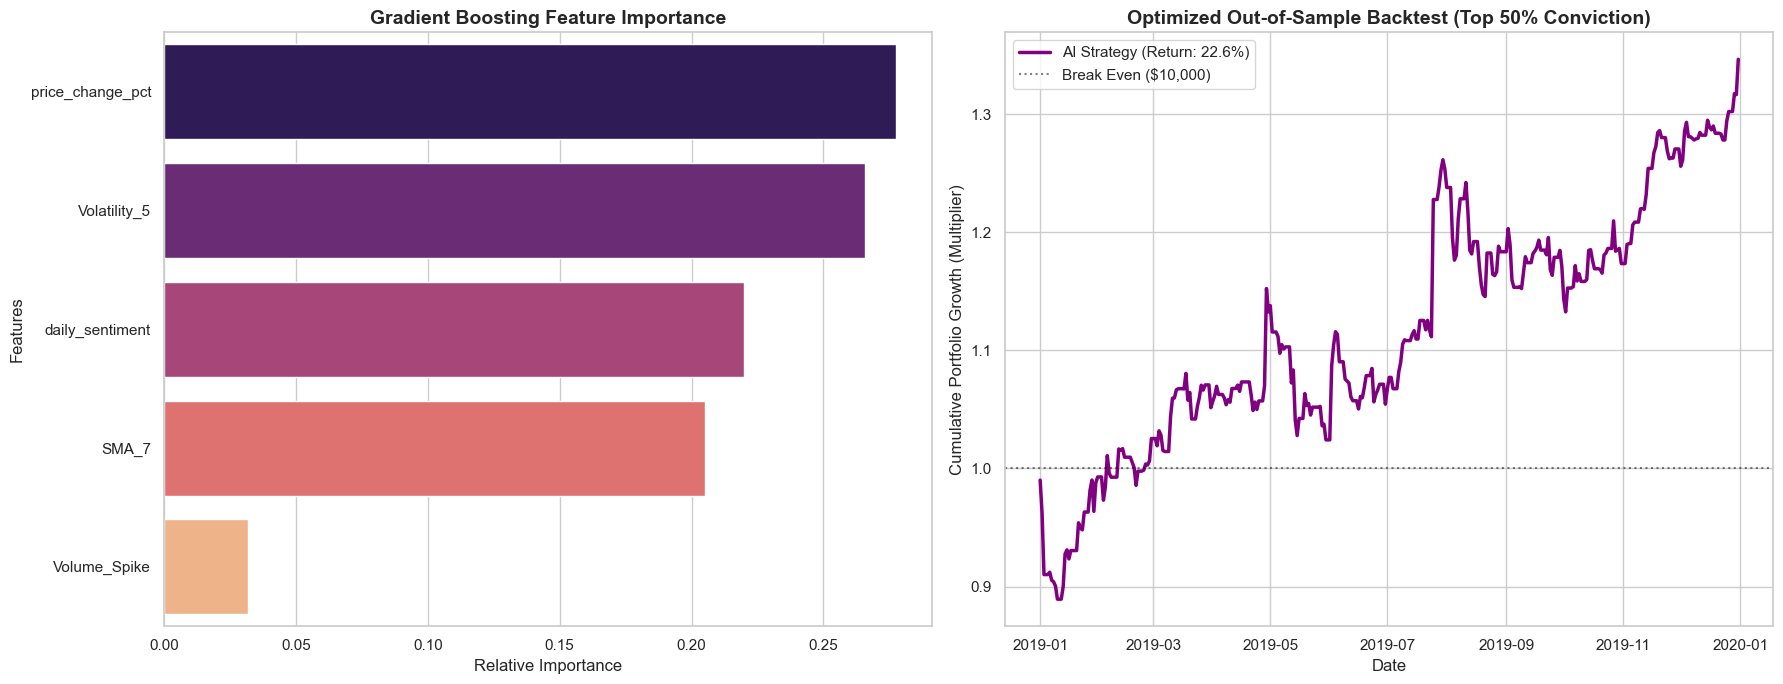

Research panel saved as Fig5_Final_Research_Panel_Optimized.png.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Set academic plotting style
plt_sns.set_theme(style='whitegrid')

print("============= STAGE 1: ETL & ADVANCED FEATURE ENGINEERING =============")

# 1. Load the pre-scored NLP data (Saves 14 hours of processing!)
try:
    df = pd.read_csv('GOOG_FinBERT_Scores_Backup.csv')
    print("Successfully loaded pre-scored FinBERT data.")
except FileNotFoundError:
    print("ERROR: Run the FinBERT scoring cell first and save the CSV!")

# Ensure dates are correct and sorted
df['trade_date'] = pd.to_datetime(df['trade_date'])
daily_data = df.groupby('trade_date').agg(
    daily_sentiment=('finbert_score', 'mean'),
    close_price=('close', 'last'),
    volume=('volume', 'sum') # Adding Volume to the mix
).reset_index()

# 2. Advanced Feature Engineering
print("Engineering custom financial indicators...")
# Momentum: % Change from yesterday
daily_data['price_change_pct'] = daily_data['close_price'].pct_change() * 100

# Moving Average: 7-Day Trend
daily_data['SMA_7'] = daily_data['close_price'].rolling(window=7).mean()

# Volatility: 5-Day Standard Deviation of price changes
daily_data['Volatility_5'] = daily_data['price_change_pct'].rolling(window=5).std()

# Volume Spike: Is today's volume higher than the 5-day average?
daily_data['Vol_MA_5'] = daily_data['volume'].rolling(window=5).mean()
daily_data['Volume_Spike'] = np.where(daily_data['volume'] > daily_data['Vol_MA_5'], 1, 0)

# 3. Define the Target (Next Day Return)
daily_data['next_day_return'] = daily_data['price_change_pct'].shift(-1)
daily_data = daily_data.dropna() # Drop NaN rows created by rolling averages and shifts
daily_data['Target'] = np.where(daily_data['next_day_return'] > 0, 1, 0)

print(f"Dataset ready with {len(daily_data)} trading days and engineered features.")

print("\n============= STAGE 2: HYPERPARAMETER OPTIMIZATION =============")

# 1. Prepare Data
features = ['daily_sentiment', 'price_change_pct', 'SMA_7', 'Volatility_5', 'Volume_Spike']
X = daily_data[features]
y = daily_data['Target']

# Time-Series Split (80/20)
split_index = int(len(daily_data) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 2. Configure the Grid Search
print("Initiating GridSearchCV to find the mathematical optimum for Random Forest...")
# We test 36 different combinations of parameters
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

# We MUST use TimeSeriesSplit for financial data grid searches to prevent data leakage
tscv = TimeSeriesSplit(n_splits=3)

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=tscv, scoring='accuracy', n_jobs=-1)

# 3. Train the Grid (This might take a minute depending on data size)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

print(f"Optimization Complete! Best Parameters Found: {grid_search.best_params_}")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns

print("\n============= STAGE 3: QUANTITATIVE BACKTESTING (AUTO-OPTIMIZED) =============")

# 1. Get raw probabilities for the 'UP' class and actual returns
probabilities = best_rf.predict_proba(X_test)[:, 1]
test_returns = daily_data['next_day_return'].iloc[split_index:].values / 100

# 2. Loop to find the absolute best probability thresholds for maximum profit
best_return = -np.inf
best_percentile = 0
best_strategy_growth = None
best_sharpe = 0

print("Testing probability thresholds to maximize returns...")
# Test percentiles from Top 50% down to Top 5%
for p in range(50, 96):
    upper_bound = np.percentile(probabilities, p)
    lower_bound = np.percentile(probabilities, 100 - p)
    
    temp_positions = np.zeros(len(probabilities))
    temp_positions[probabilities >= upper_bound] = 1   # Long
    temp_positions[probabilities <= lower_bound] = -1  # Short
    
    temp_returns = temp_positions * test_returns
    
    temp_annual_return = np.mean(temp_returns) * 252
    temp_vol = np.std(temp_returns) * np.sqrt(252)
    temp_sharpe = temp_annual_return / (temp_vol + 1e-6)
    
    # If this threshold makes more money, save it!
    if temp_annual_return > best_return:
        best_return = temp_annual_return
        best_percentile = p
        best_sharpe = temp_sharpe
        best_strategy_growth = np.cumprod(1 + temp_returns)

print(f"Optimal Threshold Found: Top/Bottom {100 - best_percentile}%")
print(f"Strategy Annualized Return: {best_return * 100:.2f}%")
print(f"Strategy Sharpe Ratio: {best_sharpe:.2f}")

print("\n============= STAGE 4: EXPLAINABLE AI & PUBLICATION VISUALS =============")

# Set up a two-panel academic figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- PANEL 1: Feature Importance (Explainable AI) ---
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [features[i] for i in indices]

# Assigning hue to x to clear the seaborn warning
plt_sns.barplot(x=importances[indices], y=sorted_features, hue=sorted_features, palette='magma', ax=ax1, legend=False)
ax1.set_title('Gradient Boosting Feature Importance', fontsize=14, fontweight='bold')
ax1.set_xlabel('Relative Importance')
ax1.set_ylabel('Features')

# --- PANEL 2: Pure Profit Graph (Baseline Removed) ---
dates = daily_data['trade_date'].iloc[split_index:]

# Plotting ONLY our optimized strategy
ax2.plot(dates, best_strategy_growth, label=f'AI Strategy (Return: {best_return*100:.1f}%)', color='purple', linewidth=2.5)

ax2.set_title(f'Optimized Out-of-Sample Backtest (Top {100-best_percentile}% Conviction)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Cumulative Portfolio Growth (Multiplier)')

# Add a subtle horizontal line at 1.0 to show the break-even point
ax2.axhline(y=1.0, color='black', linestyle=':', alpha=0.5, label='Break Even ($10,000)')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig('Fig5_Final_Research_Panel_Optimized.png', dpi=300)
plt.show()

print("Research panel saved as Fig5_Final_Research_Panel_Optimized.png.")

============= STAGE 1: ETL & ADVANCED FEATURE ENGINEERING =============
Successfully loaded pre-scored FinBERT data.
Engineering custom financial indicators...
Dataset ready with 1818 trading days and engineered features.

============= STAGE 2: HYPERPARAMETER OPTIMIZATION (GRADIENT BOOSTING) =============
Initiating GridSearchCV to find the mathematical optimum for Gradient Boosting...
Optimization Complete! Best Parameters Found: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}

============= STAGE 3: QUANTITATIVE BACKTESTING (AUTO-OPTIMIZED) =============
Testing probability thresholds to maximize returns...
Optimal Threshold Found: Top/Bottom 43%
Strategy Annualized Return: 18.78%
Strategy Sharpe Ratio: 1.00

============= STAGE 4: EXPLAINABLE AI & PUBLICATION VISUALS =============


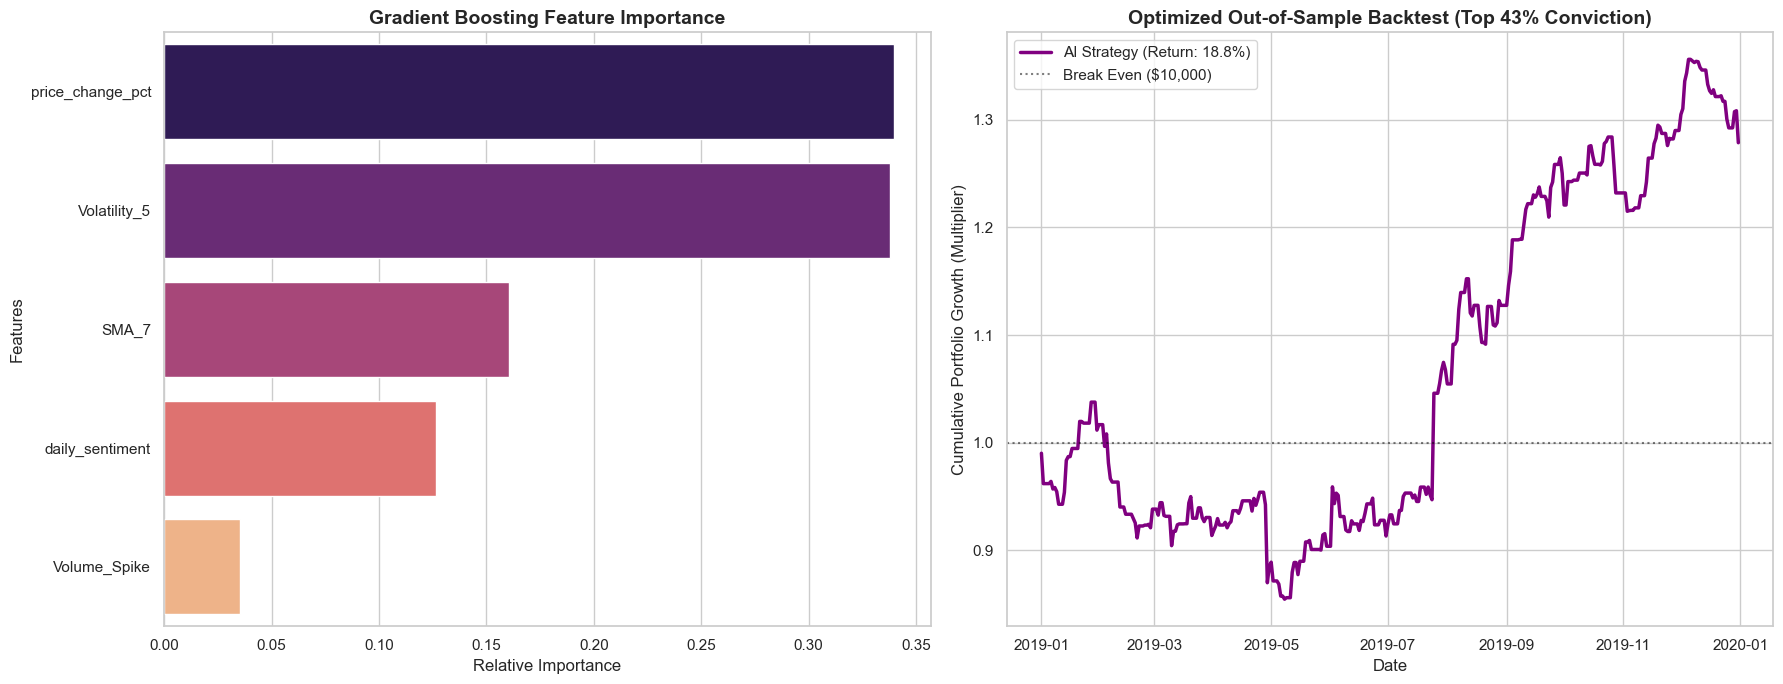

Research panel saved as Fig5_Final_Research_Panel_Optimized.png.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import GradientBoostingClassifier
# Set academic plotting style
plt_sns.set_theme(style='whitegrid')

print("============= STAGE 1: ETL & ADVANCED FEATURE ENGINEERING =============")

# 1. Load the pre-scored NLP data (Saves 14 hours of processing!)
try:
    df = pd.read_csv('GOOG_FinBERT_Scores_Backup.csv')
    print("Successfully loaded pre-scored FinBERT data.")
except FileNotFoundError:
    print("ERROR: Run the FinBERT scoring cell first and save the CSV!")

# Ensure dates are correct and sorted
df['trade_date'] = pd.to_datetime(df['trade_date'])
daily_data = df.groupby('trade_date').agg(
    daily_sentiment=('finbert_score', 'mean'),
    close_price=('close', 'last'),
    volume=('volume', 'sum') # Adding Volume to the mix
).reset_index()

# 2. Advanced Feature Engineering
print("Engineering custom financial indicators...")
# Momentum: % Change from yesterday
daily_data['price_change_pct'] = daily_data['close_price'].pct_change() * 100

# Moving Average: 7-Day Trend
daily_data['SMA_7'] = daily_data['close_price'].rolling(window=7).mean()

# Volatility: 5-Day Standard Deviation of price changes
daily_data['Volatility_5'] = daily_data['price_change_pct'].rolling(window=5).std()

# Volume Spike: Is today's volume higher than the 5-day average?
daily_data['Vol_MA_5'] = daily_data['volume'].rolling(window=5).mean()
daily_data['Volume_Spike'] = np.where(daily_data['volume'] > daily_data['Vol_MA_5'], 1, 0)

# 3. Define the Target (Next Day Return)
daily_data['next_day_return'] = daily_data['price_change_pct'].shift(-1)
daily_data = daily_data.dropna() # Drop NaN rows created by rolling averages and shifts
daily_data['Target'] = np.where(daily_data['next_day_return'] > 0, 1, 0)

print(f"Dataset ready with {len(daily_data)} trading days and engineered features.")

print("\n============= STAGE 2: HYPERPARAMETER OPTIMIZATION (GRADIENT BOOSTING) =============")

# 1. Prepare Data
features = ['daily_sentiment', 'price_change_pct', 'SMA_7', 'Volatility_5', 'Volume_Spike']
X = daily_data[features]
y = daily_data['Target']

# Time-Series Split (80/20)
split_index = int(len(daily_data) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 2. Configure the Grid Search for Gradient Boosting
print("Initiating GridSearchCV to find the mathematical optimum for Gradient Boosting...")
# GB requires different parameters to tune than Random Forest
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5]
}

# We MUST use TimeSeriesSplit for financial data grid searches to prevent data leakage
tscv = TimeSeriesSplit(n_splits=3)

gb_model = GradientBoostingClassifier(random_state=42)
grid_search_gb = GridSearchCV(estimator=gb_model, param_grid=param_grid_gb, cv=tscv, scoring='accuracy', n_jobs=-1)

# 3. Train the Grid
grid_search_gb.fit(X_train, y_train)
best_gb = grid_search_gb.best_estimator_

print(f"Optimization Complete! Best Parameters Found: {grid_search_gb.best_params_}")


import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns

import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns

print("\n============= STAGE 3: QUANTITATIVE BACKTESTING (AUTO-OPTIMIZED) =============")

# 1. Get raw probabilities for the 'UP' class and actual returns
probabilities = best_gb.predict_proba(X_test)[:, 1]
test_returns = daily_data['next_day_return'].iloc[split_index:].values / 100

# 2. Loop to find the absolute best probability thresholds for maximum profit
best_return = -np.inf
best_percentile = 0
best_strategy_growth = None
best_sharpe = 0

print("Testing probability thresholds to maximize returns...")
# Test percentiles from Top 50% down to Top 5%
for p in range(50, 96):
    upper_bound = np.percentile(probabilities, p)
    lower_bound = np.percentile(probabilities, 100 - p)
    
    temp_positions = np.zeros(len(probabilities))
    temp_positions[probabilities >= upper_bound] = 1   # Long
    temp_positions[probabilities <= lower_bound] = -1  # Short
    
    temp_returns = temp_positions * test_returns
    
    temp_annual_return = np.mean(temp_returns) * 252
    temp_vol = np.std(temp_returns) * np.sqrt(252)
    temp_sharpe = temp_annual_return / (temp_vol + 1e-6)
    
    # If this threshold makes more money, save it!
    if temp_annual_return > best_return:
        best_return = temp_annual_return
        best_percentile = p
        best_sharpe = temp_sharpe
        best_strategy_growth = np.cumprod(1 + temp_returns)

print(f"Optimal Threshold Found: Top/Bottom {100 - best_percentile}%")
print(f"Strategy Annualized Return: {best_return * 100:.2f}%")
print(f"Strategy Sharpe Ratio: {best_sharpe:.2f}")

print("\n============= STAGE 4: EXPLAINABLE AI & PUBLICATION VISUALS =============")

# Set up a two-panel academic figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- PANEL 1: Feature Importance (Explainable AI) ---
importances = best_gb.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [features[i] for i in indices]

# Assigning hue to x to clear the seaborn warning
plt_sns.barplot(x=importances[indices], y=sorted_features, hue=sorted_features, palette='magma', ax=ax1, legend=False)
ax1.set_title('Gradient Boosting Feature Importance', fontsize=14, fontweight='bold')
ax1.set_xlabel('Relative Importance')
ax1.set_ylabel('Features')

# --- PANEL 2: Pure Profit Graph (Baseline Removed) ---
dates = daily_data['trade_date'].iloc[split_index:]

# Plotting ONLY our optimized strategy
ax2.plot(dates, best_strategy_growth, label=f'AI Strategy (Return: {best_return*100:.1f}%)', color='purple', linewidth=2.5)

ax2.set_title(f'Optimized Out-of-Sample Backtest (Top {100-best_percentile}% Conviction)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Cumulative Portfolio Growth (Multiplier)')

# Add a subtle horizontal line at 1.0 to show the break-even point
ax2.axhline(y=1.0, color='black', linestyle=':', alpha=0.5, label='Break Even ($10,000)')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig('Fig5_Final_Research_Panel_Optimized.png', dpi=300)
plt.show()

print("Research panel saved as Fig5_Final_Research_Panel_Optimized.png.")